# Daily Market Scan
Quick overview of all tracked symbols: movers, volume, volatility, regime.
Run this every morning to get market context before doing deeper research.

In [1]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv()

ch = clickhouse_connect.get_client(
    host=os.getenv('CLICKHOUSE_HOST', 'clickhouse'),
    port=int(os.getenv('CLICKHOUSE_HTTP_PORT', '8123')),
    database=os.getenv('CLICKHOUSE_DB', 'crypto'),
    username=os.getenv('CLICKHOUSE_USER', 'crypto_user'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
)
print('Connected to ClickHouse')

Connected to ClickHouse


## 1. Top Movers (24h)

In [2]:
movers = ch.query_df("""
SELECT
    symbol,
    round(argMin(open,  open_time), 4) AS open_24h,
    round(argMax(close, open_time), 4) AS close_24h,
    round(max(high), 4)                AS high_24h,
    round(min(low),  4)                AS low_24h,
    round((argMax(close,open_time) - argMin(open,open_time))
          / nullIf(argMin(open,open_time),0) * 100, 2) AS pct_change_24h,
    round(sum(quote_volume) / 1e6, 2)  AS quote_vol_M
FROM crypto.fact_candles
WHERE interval = '1m' AND open_time >= now() - INTERVAL 24 HOUR
GROUP BY symbol
ORDER BY abs(pct_change_24h) DESC
""")
display(movers)

,symbol,open_24h,close_24h,high_24h,low_24h,pct_change_24h,quote_vol_M
0,BTC/USDT,71506.6700,67293.3400,71690.0000,67076.0000,-5.89,0.0
1,SOL/USDT,81.0000,76.3300,81.6500,75.5800,-5.77,0.0
2,XRP/USDT,1.2984,1.2243,1.3015,1.2171,-5.71,0.0
3,BNB/USDT,694.3800,665.8600,701.7300,658.0000,-4.11,0.0
4,ETH/USDT,1992.6100,1913.3400,2009.2000,1890.0000,-3.98,0.0


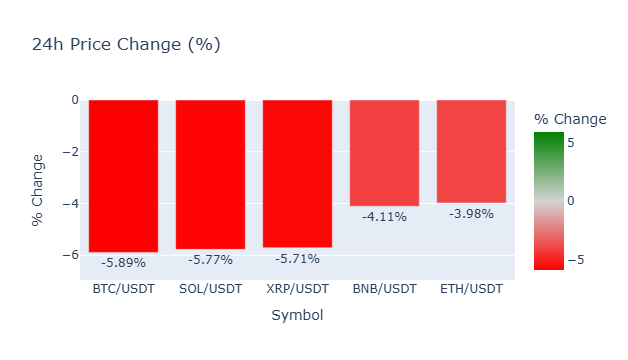

In [3]:
fig = px.bar(
    movers, x='symbol', y='pct_change_24h',
    color='pct_change_24h',
    color_continuous_scale=['red', 'lightgrey', 'green'],
    color_continuous_midpoint=0,
    title='24h Price Change (%)',
    labels={'pct_change_24h': '% Change', 'symbol': 'Symbol'},
    text='pct_change_24h'
)
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.show()

## 2. Volatility Snapshot

In [4]:
vol = ch.query_df("""
SELECT symbol,
    round(realized_vol_7d  * 100, 1) AS vol_7d_pct,
    round(realized_vol_30d * 100, 1) AS vol_30d_pct,
    round(realized_vol_7d / nullIf(realized_vol_30d,0), 2) AS vol_ratio,
    round(avg_true_range, 4) AS atr_14d
FROM crypto.mart_volatility
WHERE (exchange, symbol, window_start) IN (
    SELECT exchange, symbol, max(window_start)
    FROM crypto.mart_volatility GROUP BY exchange, symbol
)
ORDER BY vol_30d_pct DESC
""")
display(vol)

,symbol,vol_7d_pct,vol_30d_pct,vol_ratio,atr_14d
0,BNB/USDT,88.9,48.3,1.84,27.6986
1,SOL/USDT,41.3,44.3,0.93,3.2579
2,XRP/USDT,43.6,39.5,1.10,0.0461
3,BTC/USDT,39.4,32.6,1.21,2055.8600
4,ETH/USDT,32.7,31.3,1.05,71.2571


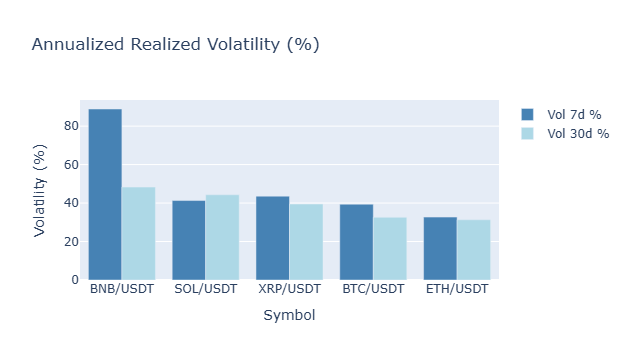

In [5]:
fig = go.Figure()
fig.add_trace(go.Bar(name='Vol 7d %',  x=vol['symbol'], y=vol['vol_7d_pct'],  marker_color='steelblue'))
fig.add_trace(go.Bar(name='Vol 30d %', x=vol['symbol'], y=vol['vol_30d_pct'], marker_color='lightblue'))
fig.update_layout(barmode='group', title='Annualized Realized Volatility (%)',
                  yaxis_title='Volatility (%)', xaxis_title='Symbol')
fig.show()

## 3. Volume Activity (last 24h by hour)

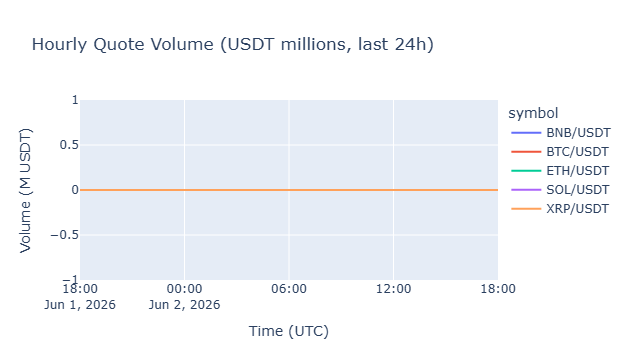

In [6]:
hourly_vol = ch.query_df("""
SELECT
    symbol,
    toStartOfHour(open_time) AS hour,
    round(sum(quote_volume) / 1e6, 2) AS quote_vol_M
FROM crypto.fact_candles
WHERE interval = '1m' AND open_time >= now() - INTERVAL 24 HOUR
GROUP BY symbol, hour
ORDER BY symbol, hour
""")

fig = px.line(hourly_vol, x='hour', y='quote_vol_M', color='symbol',
              title='Hourly Quote Volume (USDT millions, last 24h)',
              labels={'quote_vol_M': 'Volume (M USDT)', 'hour': 'Time (UTC)'})
fig.show()

## 4. Market Regime Summary

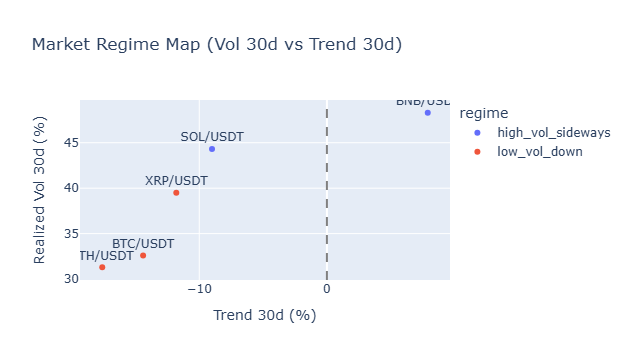

In [7]:
regime = ch.query_df("""
WITH daily_close AS (
    SELECT symbol, toDate(open_time) AS d, argMax(close, open_time) AS c
    FROM crypto.fact_candles WHERE interval='1m' AND open_time >= now() - INTERVAL 30 DAY
    GROUP BY symbol, d
),
trend AS (
    SELECT symbol,
        round((argMax(c,d) - argMin(c,d)) / nullIf(argMin(c,d),0)*100, 1) AS trend_pct
    FROM daily_close GROUP BY symbol
)
SELECT v.symbol,
    round(v.realized_vol_30d*100,1) AS vol_30d,
    t.trend_pct,
    CASE
        WHEN v.realized_vol_30d > 0.4 AND t.trend_pct >  10 THEN 'high_vol_up'
        WHEN v.realized_vol_30d > 0.4 AND t.trend_pct < -10 THEN 'high_vol_down'
        WHEN v.realized_vol_30d > 0.4                       THEN 'high_vol_sideways'
        WHEN t.trend_pct > 5                                THEN 'low_vol_up'
        WHEN t.trend_pct < -5                               THEN 'low_vol_down'
        ELSE                                                     'low_vol_sideways'
    END AS regime
FROM crypto.mart_volatility v
JOIN trend t USING (symbol)
WHERE (v.exchange, v.symbol, v.window_start) IN (
    SELECT exchange, symbol, max(window_start) FROM crypto.mart_volatility GROUP BY exchange, symbol
)
""")

fig = px.scatter(regime, x='trend_pct', y='vol_30d', text='symbol', color='regime',
                 title='Market Regime Map (Vol 30d vs Trend 30d)',
                 labels={'trend_pct': 'Trend 30d (%)', 'vol_30d': 'Realized Vol 30d (%)'})
fig.update_traces(textposition='top center')
fig.add_vline(x=0, line_dash='dash', line_color='grey')
fig.show()